In [1]:
import cleanup
import plotting
import stat_analysis
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sbs
import math as math
import os
from os import listdir
import tkinter
from tkinter import filedialog
import scipy as scp
import scipy.stats as scpst
import framewise_stats
import bootstrapping

pd.options.mode.use_inf_as_na = True

c:\Data\Experiment Work\Larva-Locater\larva-locater\Structured\cleanup.py:13: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  pd.options.mode.use_inf_as_na = True
C:\Users\hpnhp\AppData\Local\Temp\ipykernel_41752\315590360.py:21: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  pd.options.mode.use_inf_as_na = True


In [8]:
#Loading up dataset 1

tkinter.Tk().withdraw()
filepath = filedialog.askdirectory()
primary_df_old = cleanup.data_to_dataframe(filepath)

primary_df_old = primary_df_old[primary_df_old['Frame']<600]
primary_df_old = cleanup.calculate_distance_from_fixed_point(primary_df_old)
primary_df_old = cleanup.categorize_values(primary_df_old, 'X', 14, 1.5)

primary_df_old_interp = cleanup.interpolate_missing_values(primary_df_old)
primary_df_old_interp = cleanup.calculate_distance_from_fixed_point(primary_df_old_interp)

In [9]:
# Loading up dataset 2 

tkinter.Tk().withdraw()
filepath = filedialog.askdirectory()
primary_df_new = cleanup.data_to_dataframe(filepath)

primary_df_new = primary_df_new[primary_df_new['Frame']<600]
primary_df_new = cleanup.calculate_distance_from_fixed_point(primary_df_new)
primary_df_new = cleanup.categorize_values(primary_df_new, 'X', 14, 1.5)

primary_df_new_interp = cleanup.interpolate_missing_values(primary_df_new)
primary_df_new_interp = cleanup.calculate_distance_from_fixed_point(primary_df_new_interp)

c:\Data\Experiment Work\Larva-Locater\larva-locater\Structured\plotting.py:2666: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
c:\Data\Experiment Work\Larva-Locater\larva-locater\Structured\plotting.py:2666: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
c:\Data\Experiment Work\Larva-Locater\larva-locater\Structured\plotting.py:2666: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
c:\Data\Experiment Work\Larva-Locater\larva-locat

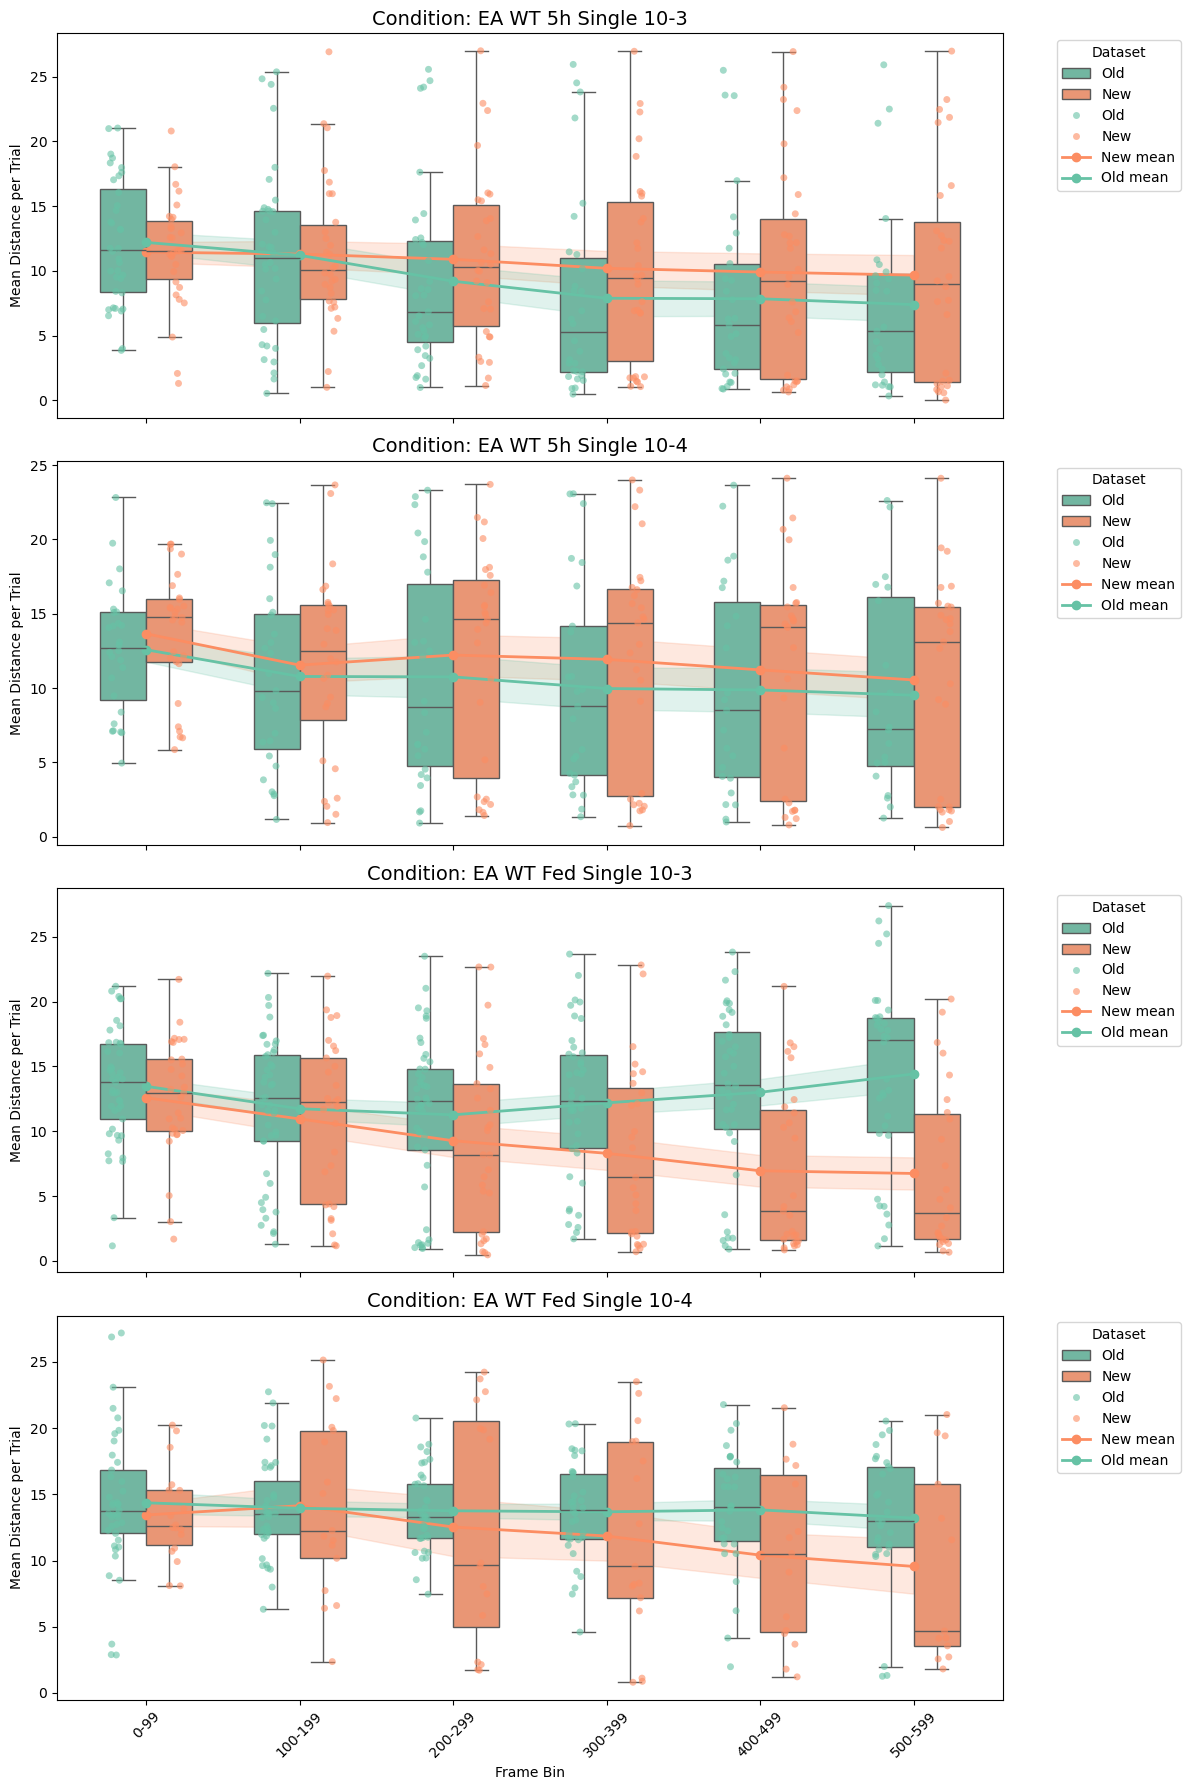

In [20]:
plotting.plot_distance_comparison_collapsed_with_summary(primary_df_old_interp, primary_df_new_interp, dataset_labels=("Old", "New"), plot_type='both')

In [2]:
# Loading up pooled dataset 

tkinter.Tk().withdraw()
filepath = filedialog.askdirectory()
primary_df_pooled = cleanup.data_to_dataframe(filepath)

primary_df_pooled = primary_df_pooled[primary_df_pooled['Frame']<600]
primary_df_pooled = cleanup.calculate_distance_from_fixed_point(primary_df_pooled)
primary_df_pooled = cleanup.categorize_values(primary_df_pooled, 'X', 14, 1.5)

primary_df_pooled_interp = cleanup.interpolate_missing_values(primary_df_pooled)
primary_df_pooled_interp = cleanup.calculate_distance_from_fixed_point(primary_df_pooled_interp)

In [6]:
primary_df_pooled_interp_plotting = primary_df_pooled_interp[primary_df_pooled_interp['Concentration'] == '10-3']
primary_df_pooled_interp_plotting = primary_df_pooled_interp_plotting[primary_df_pooled_interp_plotting['Collective'] == 'Group']#
primary_df_pooled_interp_plotting = primary_df_pooled_interp_plotting[primary_df_pooled_interp_plotting['Starvation'] == 'Fed']

c:\Data\Experiment Work\Larva-Locater\larva-locater\Structured\plotting.py:1537: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


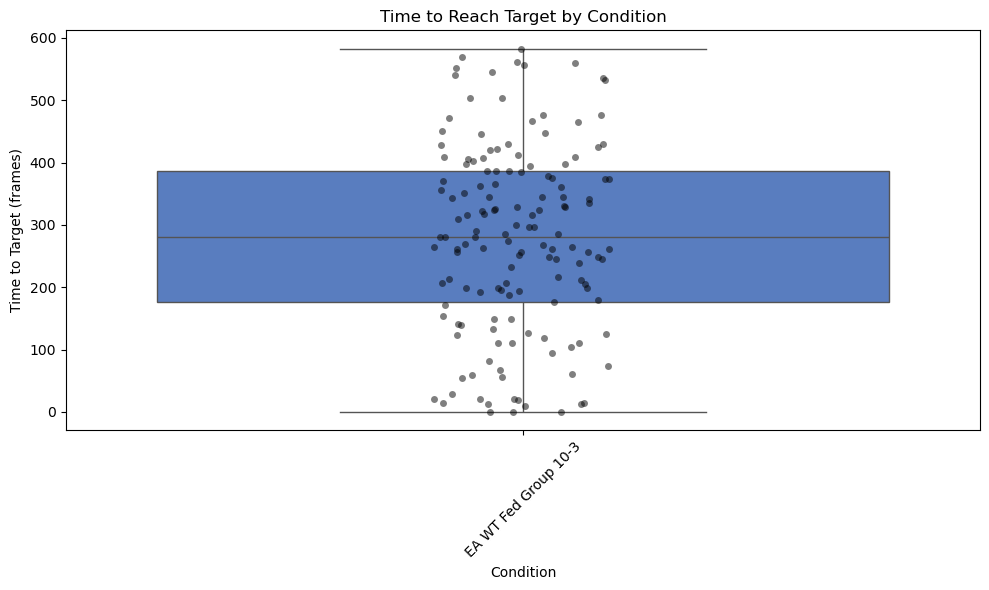

c:\Data\Experiment Work\Larva-Locater\larva-locater\Structured\plotting.py:1572: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


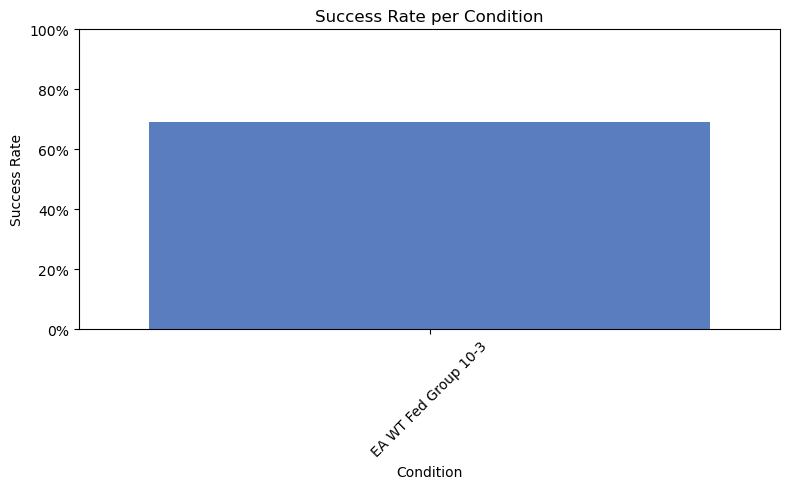

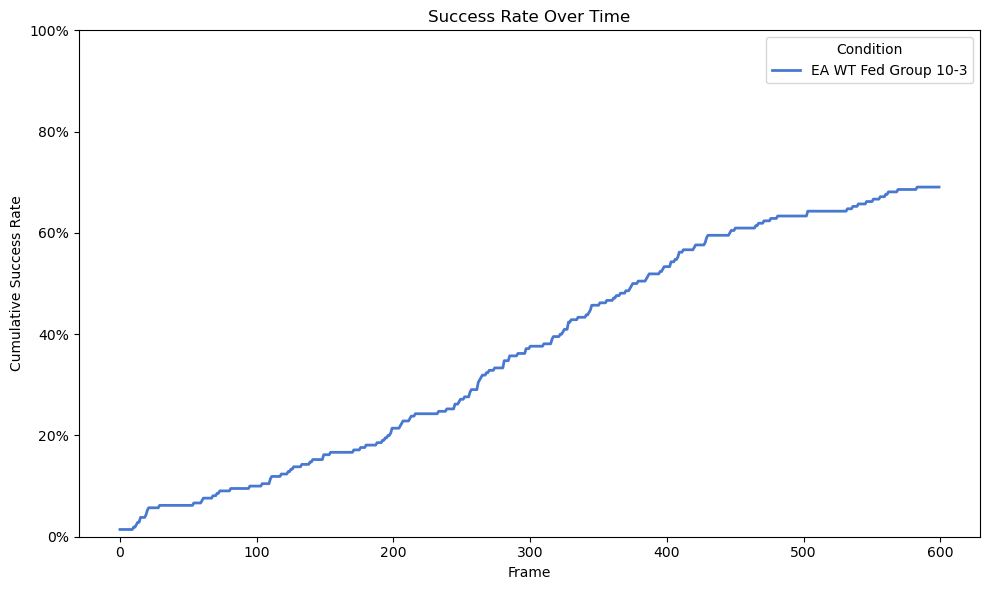

,Frame,Condition,SuccessRate
0,0.0,EA WT Fed Group 10-3,0.014286
1,1.0,EA WT Fed Group 10-3,0.014286
2,2.0,EA WT Fed Group 10-3,0.014286
3,3.0,EA WT Fed Group 10-3,0.014286
4,4.0,EA WT Fed Group 10-3,0.014286
...,...,...,...
595,595.0,EA WT Fed Group 10-3,0.690476
596,596.0,EA WT Fed Group 10-3,0.690476
597,597.0,EA WT Fed Group 10-3,0.690476
598,598.0,EA WT Fed Group 10-3,0.690476


In [9]:
plotting.analyze_and_plot_target_acquisition(primary_df_pooled_interp_plotting, assign_max_if_unreached=False)

c:\Data\Experiment Work\Larva-Locater\larva-locater\Structured\plotting.py:2957: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
c:\Data\Experiment Work\Larva-Locater\larva-locater\Structured\plotting.py:2957: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
c:\Data\Experiment Work\Larva-Locater\larva-locater\Structured\plotting.py:2957: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
c:\Data\Experiment Work\Larva-Locater\larva-locat

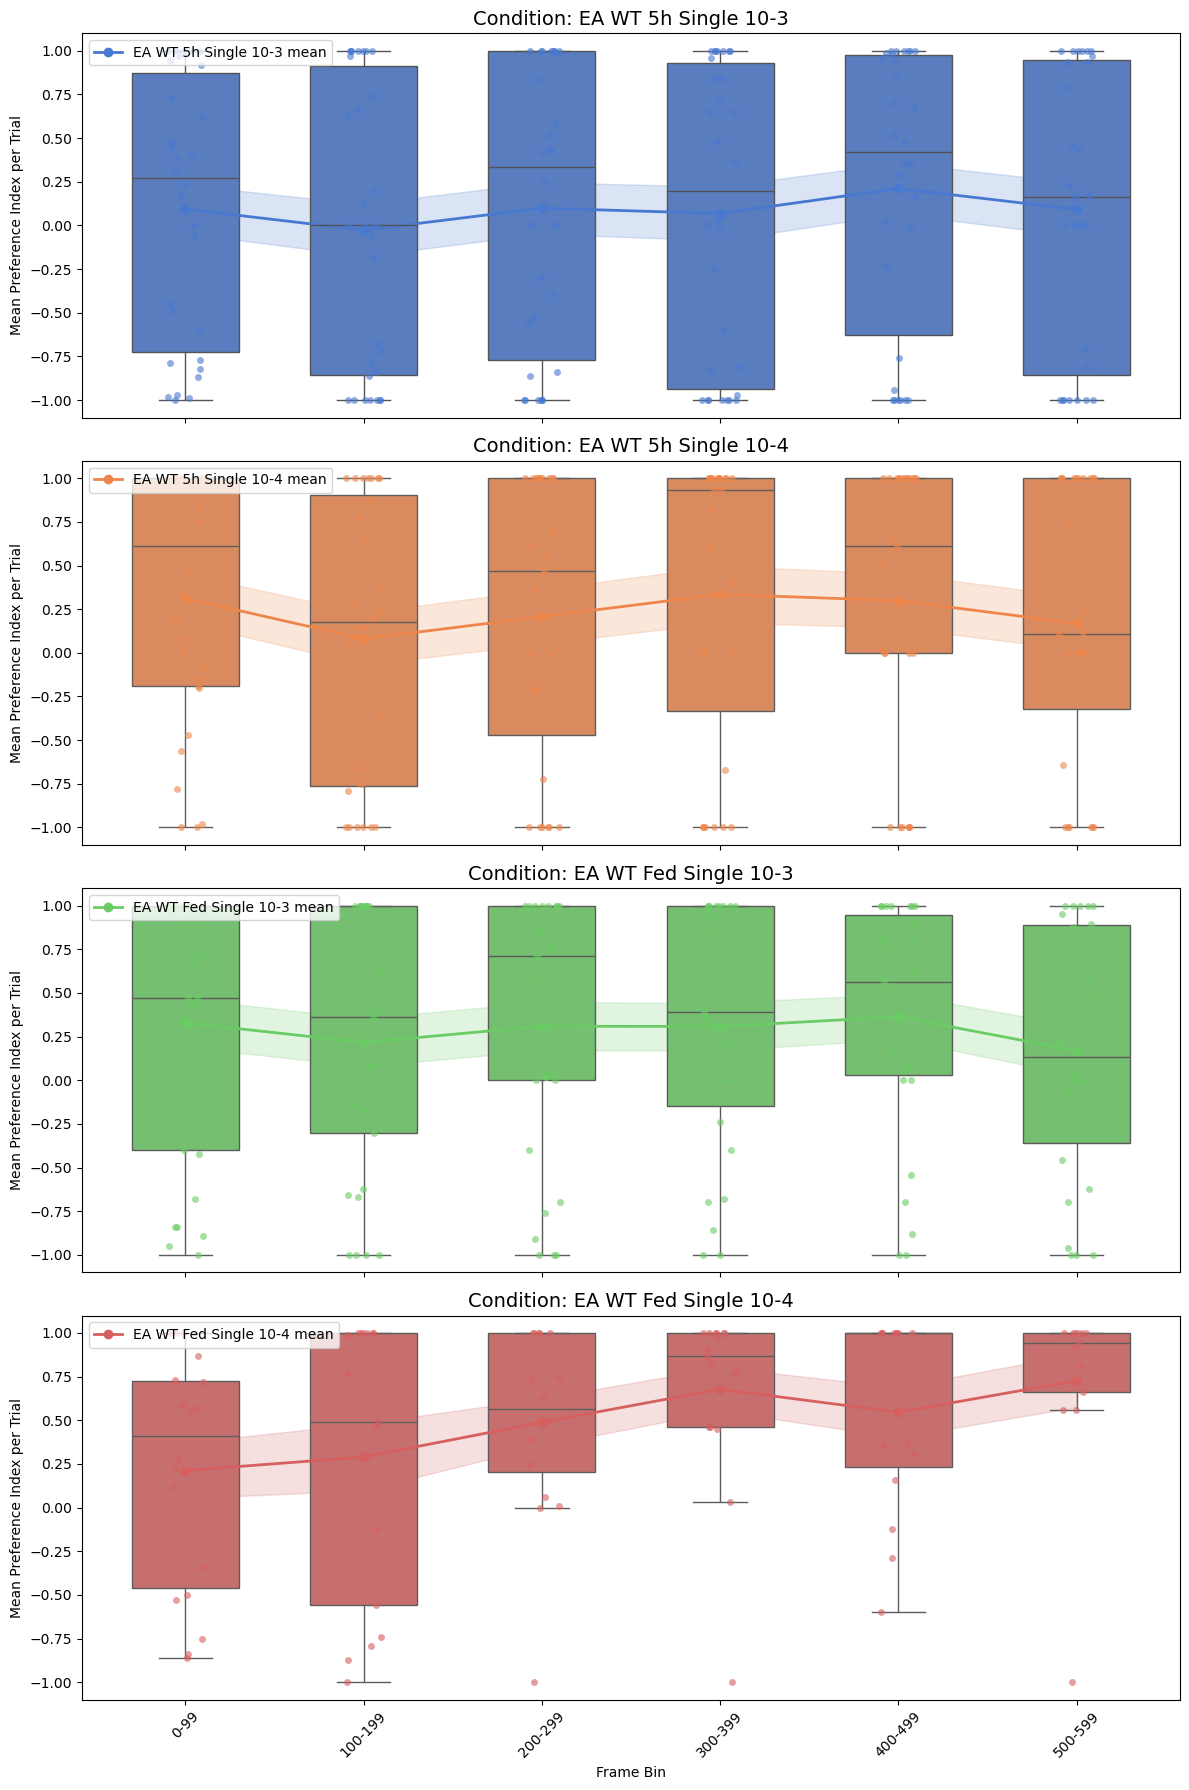

In [28]:
plotting.plot_metric_summary(primary_df_new_interp, value_col='Preference Index', plot_type='both')

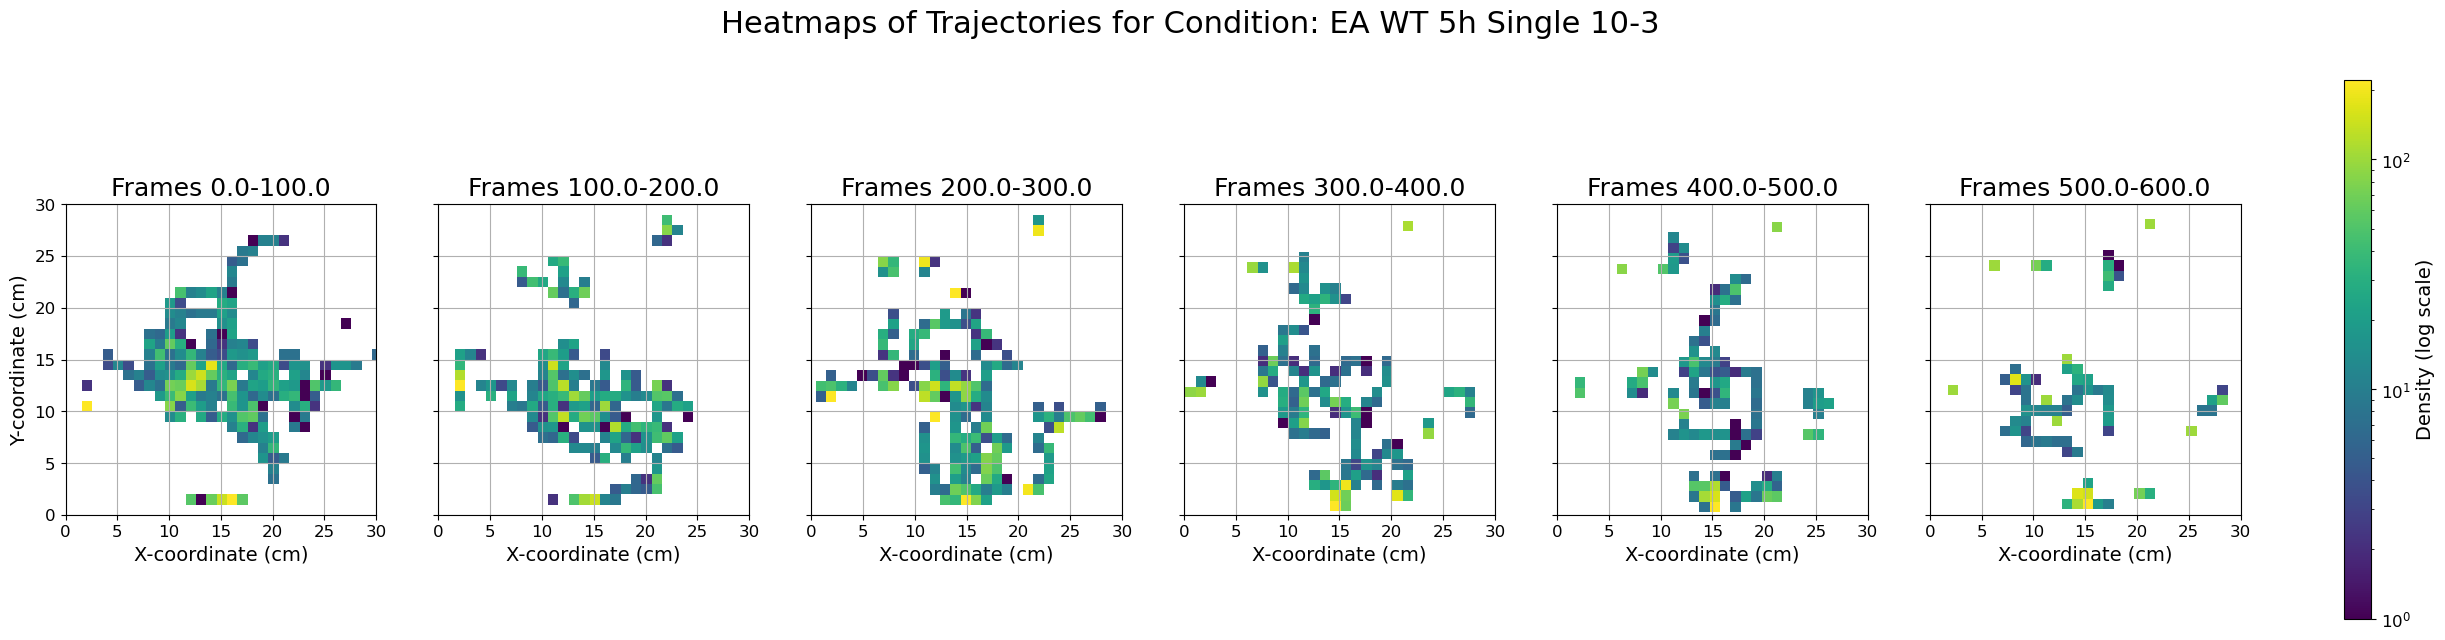

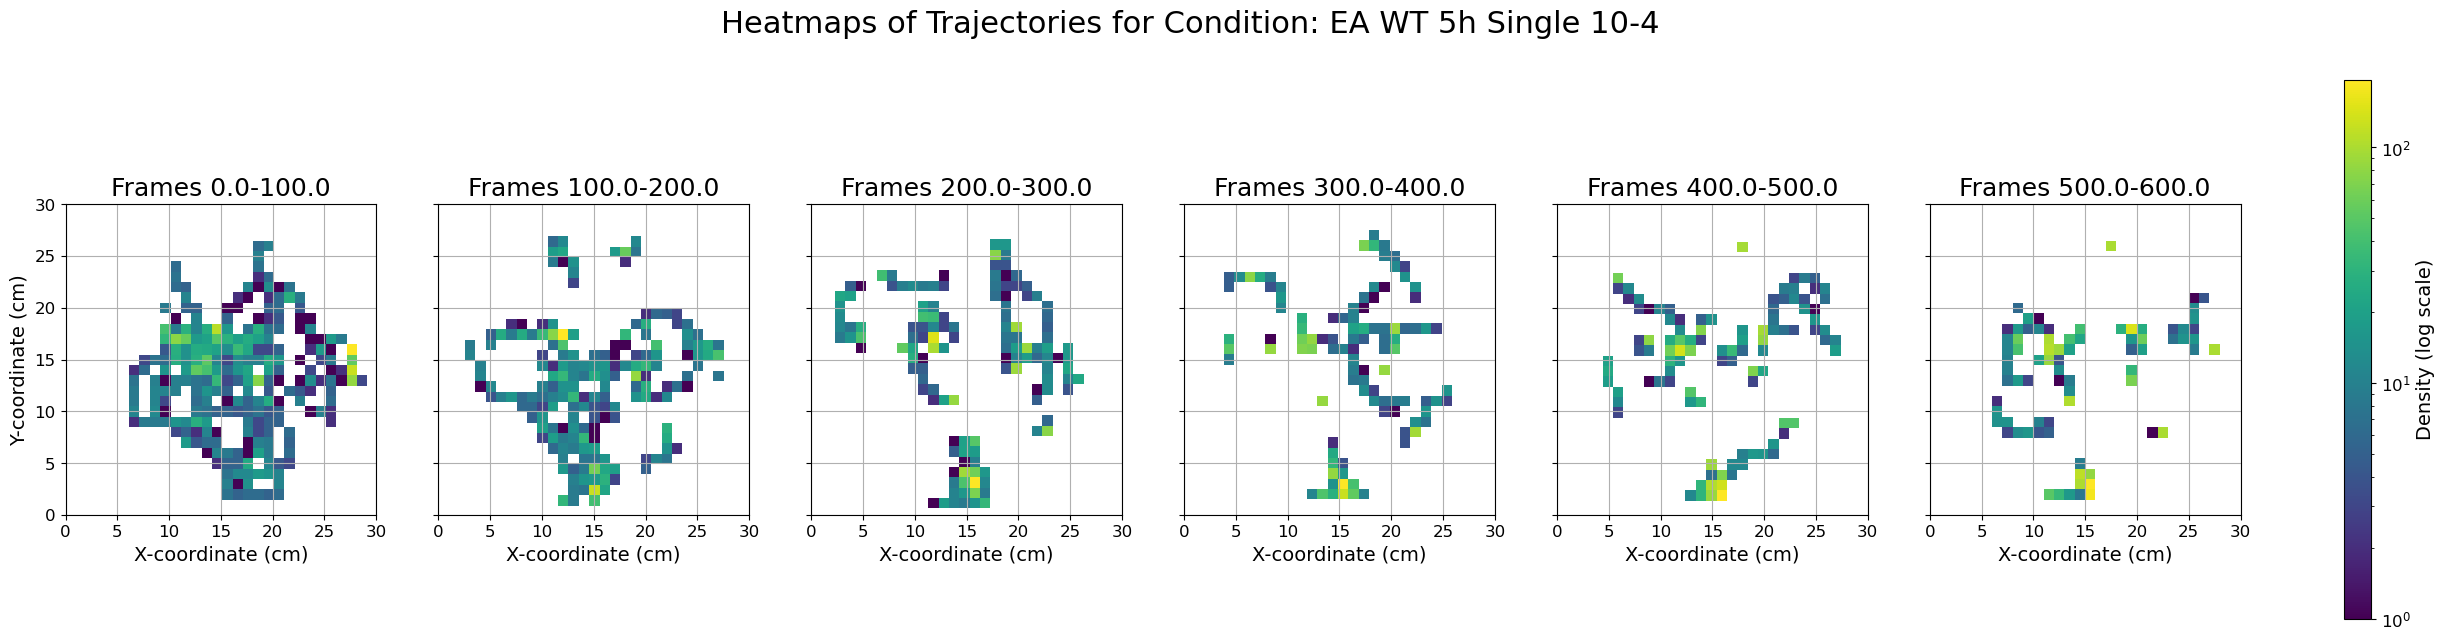

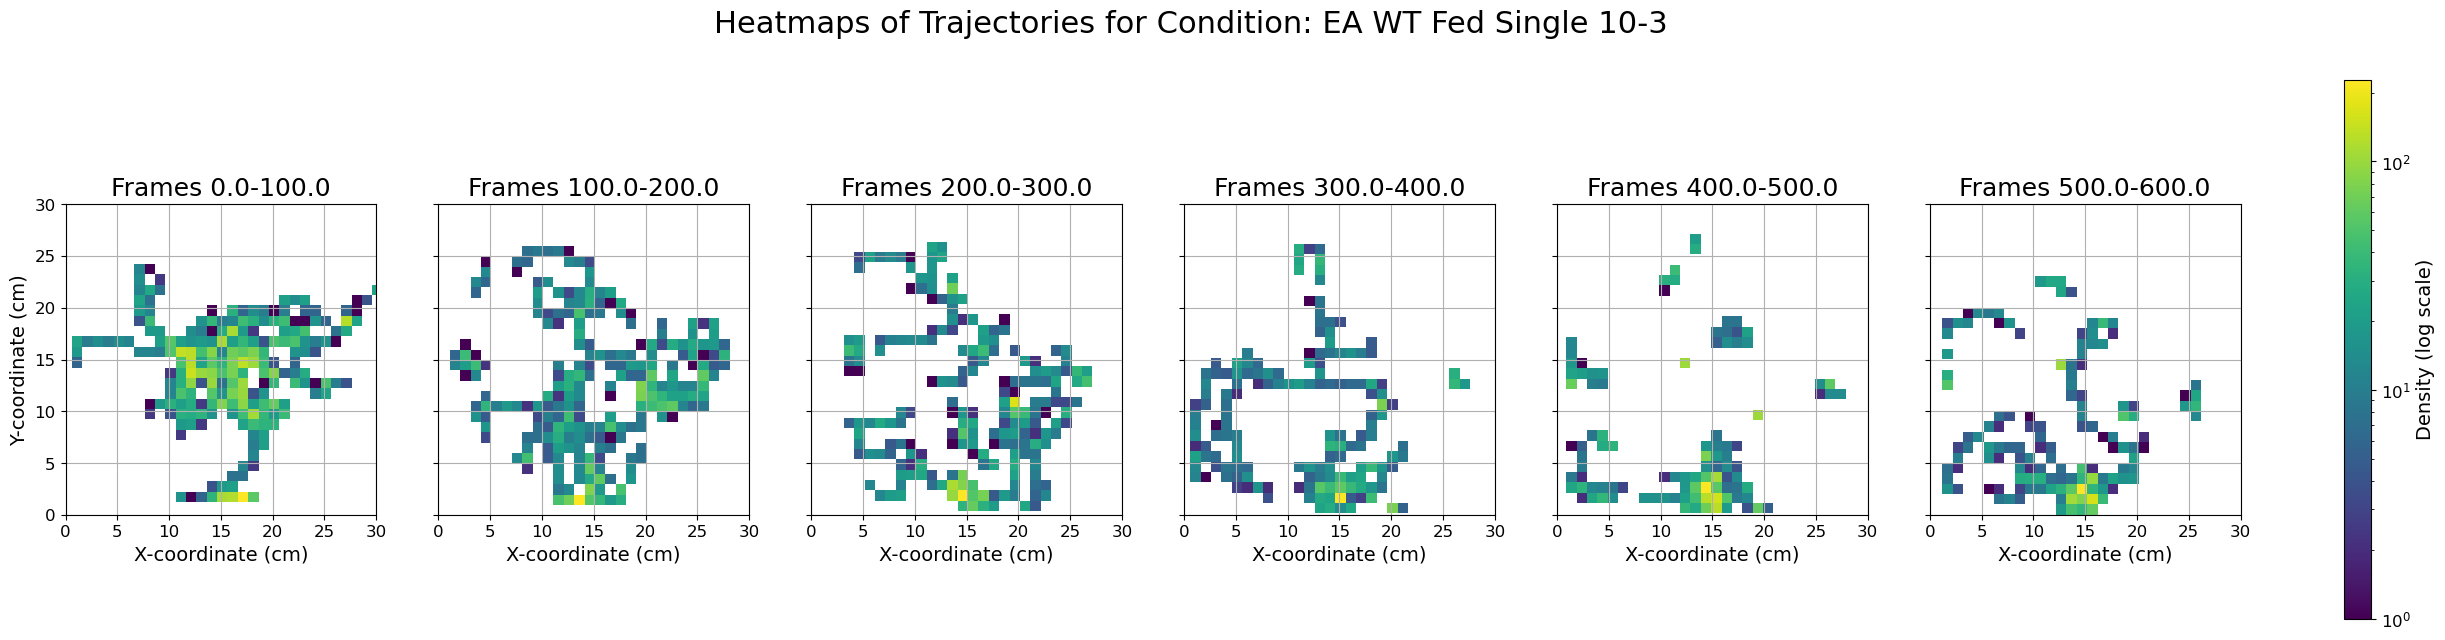

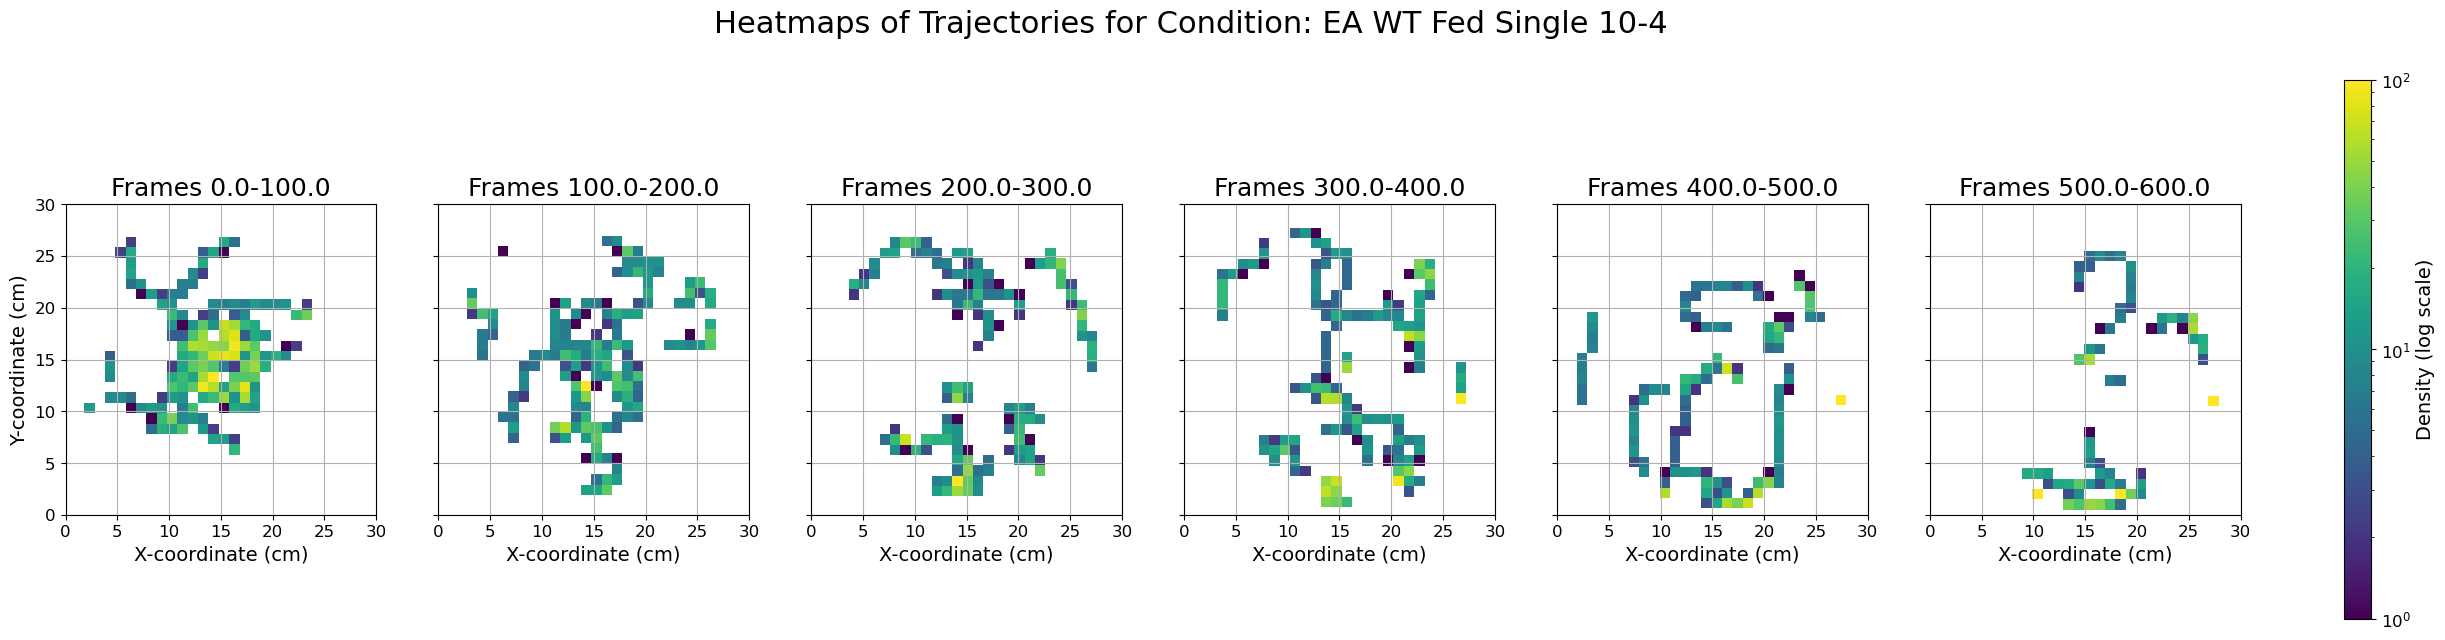

In [36]:
for cond in primary_df_new_interp['Condition'].unique():
    plotting.plot_trajectory_heatmaps(primary_df_new_interp, condition = cond)

               Condition  n_steps         R           Z     p_rayleigh  \
0   EA WT 5h Single 10-3    17004  0.115560  227.074065   1.268879e-99   
1   EA WT 5h Single 10-4    15919  0.108434  187.174992   3.085201e-82   
2  EA WT Fed Single 10-3    16108  0.149763  361.287375  1.231315e-157   
3  EA WT Fed Single 10-4     8833  0.162599  233.530430  2.344985e-102   

   mean_angle_diff_rad  mean_approach_vel  prop_steps_toward  
0            -2.534020          -0.008038           0.371089  
1            -2.655311          -0.007267           0.421949  
2            -2.645237          -0.014630           0.353489  
3            -3.071395          -0.015871           0.370429  


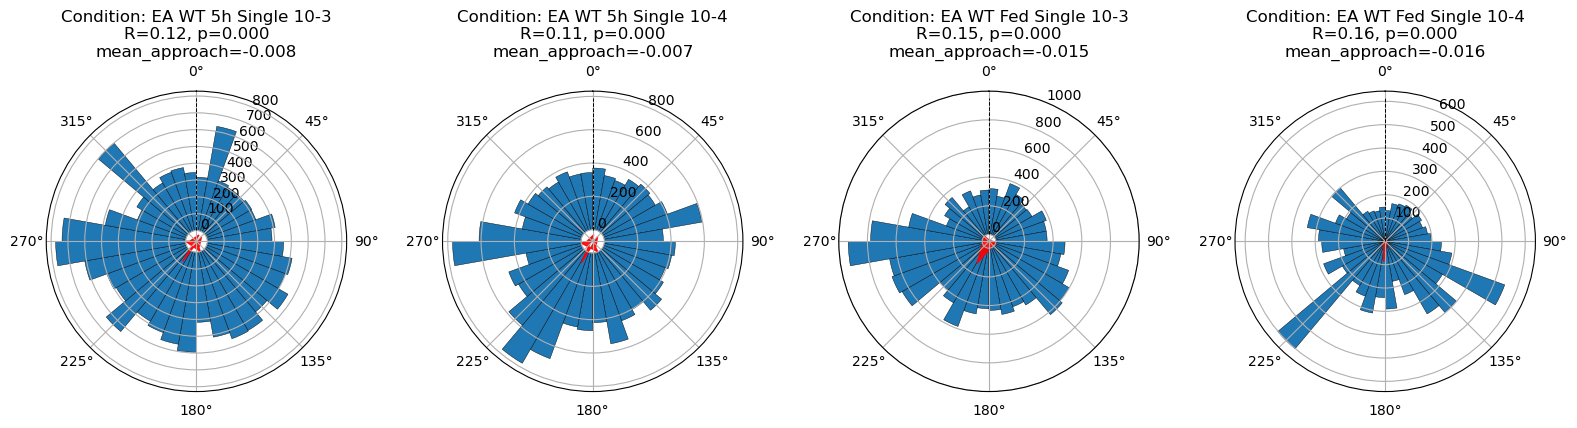

In [51]:
import velocity_analysis

fig, summary = velocity_analysis.plot_odor_attraction_rose(primary_df_new_interp, odor=(15,25), frame_range=(10,600), bins=36)
print(summary)
plt.show()